In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

pd.set_option("display.max_columns", None)

In [8]:
raw_path = "../data/raw/household_power_consumption.txt"

df = pd.read_csv(
    raw_path,
    sep=";",
    na_values=["?"],
    low_memory=False
)

df["datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    format="%d/%m/%Y %H:%M:%S"
)
df = df.drop(columns=["Date", "Time"])

print(df.shape)
df.head()


(2075259, 8)


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,datetime
0,4.216,0.418,234.84,18.4,0.0,1.0,17.0,2006-12-16 17:24:00
1,5.360,0.436,233.63,23.0,0.0,1.0,16.0,2006-12-16 17:25:00
2,5.374,0.498,233.29,23.0,0.0,2.0,17.0,2006-12-16 17:26:00
3,5.388,0.502,233.74,23.0,0.0,1.0,17.0,2006-12-16 17:27:00
4,3.666,0.528,235.68,15.8,0.0,1.0,17.0,2006-12-16 17:28:00


In [9]:
print(df.dtypes)
print()
print("Missing values per column:")
print(df.isna().sum())
print()
print(f"Total rows: {len(df)}")
print(f"Rows with at least one missing value: {df.isna().any(axis=1).sum()}")
print(f"Date range: {df['datetime'].min()} to {df['datetime'].max()}")

Global_active_power             float64
Global_reactive_power           float64
Voltage                         float64
Global_intensity                float64
Sub_metering_1                  float64
Sub_metering_2                  float64
Sub_metering_3                  float64
datetime                 datetime64[us]
dtype: object

Missing values per column:
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
datetime                     0
dtype: int64

Total rows: 2075259
Rows with at least one missing value: 25979
Date range: 2006-12-16 17:24:00 to 2010-11-26 21:02:00


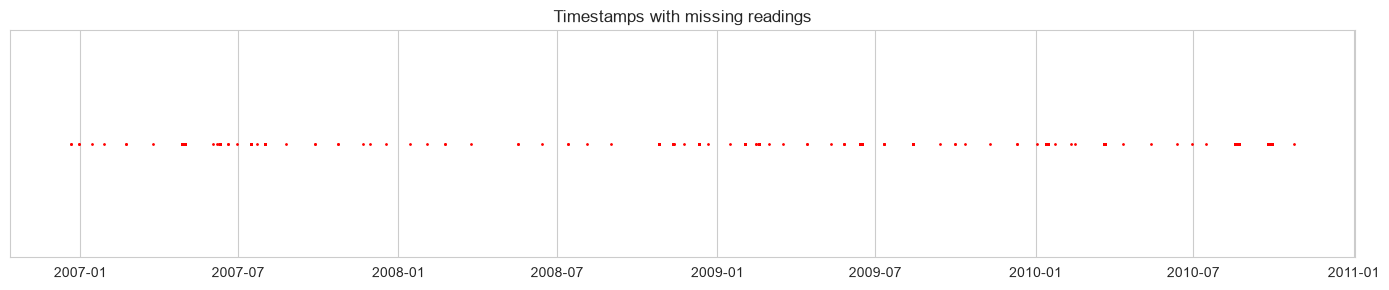

In [10]:
missing_mask = df["Global_active_power"].isna()

fig, ax = plt.subplots(figsize=(14, 3))
ax.scatter(df.loc[missing_mask, "datetime"], [1]*missing_mask.sum(), s=1, color="red")
ax.set_title("Timestamps with missing readings")
ax.set_yticks([])
plt.tight_layout()
plt.show()

In [11]:
df = df.sort_values("datetime").reset_index(drop=True)

value_cols = [
    "Global_active_power", "Global_reactive_power", "Voltage",
    "Global_intensity", "Sub_metering_1", "Sub_metering_2", "Sub_metering_3"
]

# Interpolate using linear interpolation (equivalent to averaging neighboring points,
# but handles consecutive missing rows correctly rather than just the single row before/after)
df[value_cols] = df[value_cols].interpolate(method="linear", limit_direction="both")

print("Remaining missing values after fill:")
print(df[value_cols].isna().sum())

Remaining missing values after fill:
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64


In [12]:
df_indexed = df.set_index("datetime")

df_5min = df_indexed[value_cols].resample("5min").mean()

print(f"Original rows (minute-level): {len(df_indexed)}")
print(f"Resampled rows (5-min level): {len(df_5min)}")
print()
df_5min.head()

Original rows (minute-level): 2075259
Resampled rows (5-min level): 415053



,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16 17:20:00,4.2160,0.4180,234.840,18.40,0.0,1.0,17.0
2006-12-16 17:25:00,4.6616,0.4972,234.272,19.96,0.0,1.4,16.8
2006-12-16 17:30:00,3.8360,0.5116,234.204,16.56,0.0,1.2,16.8
2006-12-16 17:35:00,4.6684,0.4100,234.212,20.00,0.0,1.0,16.8
2006-12-16 17:40:00,3.9176,0.0616,235.890,16.76,0.0,0.0,17.0


In [13]:
print("Missing values after resampling:")
print(df_5min.isna().sum())

Missing values after resampling:
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64


In [14]:
print("Summary statistics (5-min resampled data):")
print(df_5min.describe())
print()
print(f"Max Global_active_power: {df_5min['Global_active_power'].max():.3f} kW")
print(f"Mean Global_active_power: {df_5min['Global_active_power'].mean():.3f} kW")
print(f"Min Global_active_power: {df_5min['Global_active_power'].min():.3f} kW")

Summary statistics (5-min resampled data):
       Global_active_power  Global_reactive_power        Voltage  \
count        415053.000000          415053.000000  415053.000000   
mean              1.090285               0.123650     240.832772   
std               1.026049               0.105842       3.196012   
min               0.076400               0.000000     224.258000   
25%               0.313200               0.048400     239.014000   
50%               0.645200               0.100800     240.998000   
75%               1.543200               0.184800     242.846000   
max               9.721200               1.074000     253.338000   

       Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3  
count     415053.000000   415053.000000   415053.000000   415053.000000  
mean           4.621507        1.109482        1.289227        6.442400  
std            4.309724        5.673175        5.570327        8.294835  
min            0.200000        0.000000        0

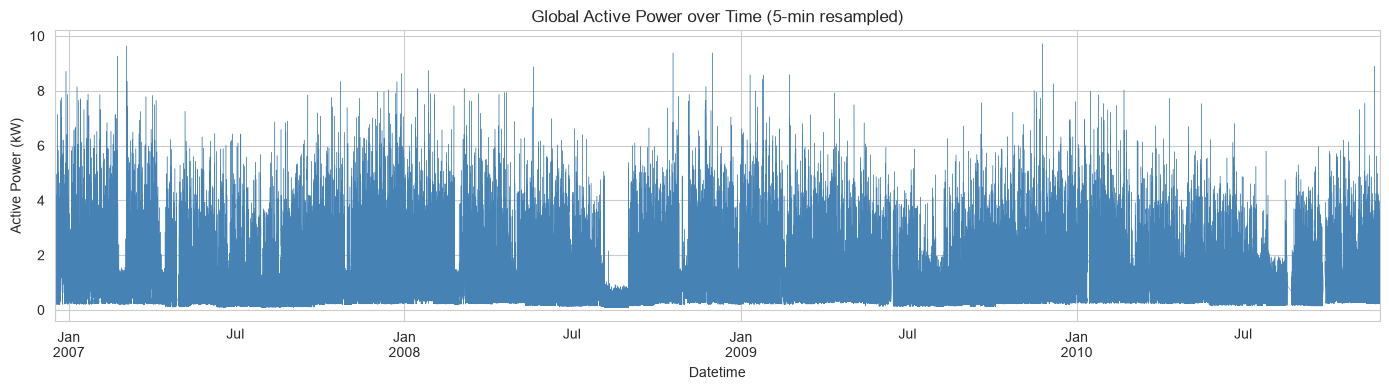

In [15]:
fig, ax = plt.subplots(figsize=(14, 4))
df_5min["Global_active_power"].plot(ax=ax, linewidth=0.3, color="steelblue")
ax.set_title("Global Active Power over Time (5-min resampled)")
ax.set_xlabel("Datetime")
ax.set_ylabel("Active Power (kW)")
plt.tight_layout()
plt.show()

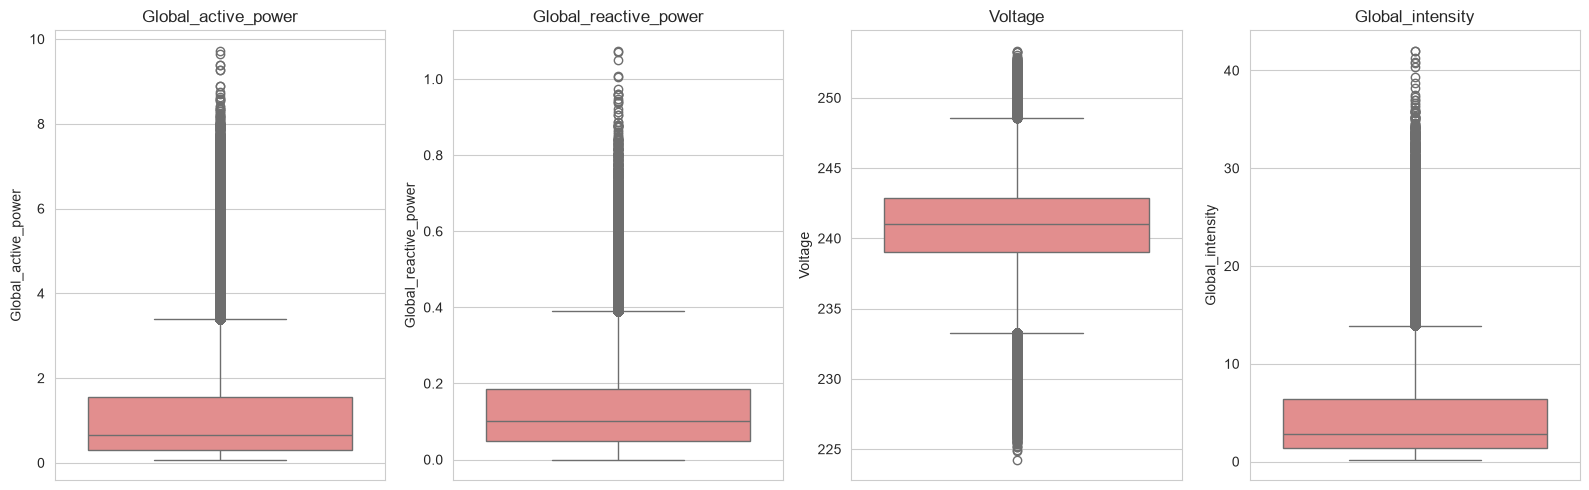

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

box_cols = ["Global_active_power", "Global_reactive_power", "Voltage", "Global_intensity"]

for ax, col in zip(axes, box_cols):
    sns.boxplot(y=df_5min[col], ax=ax, color="lightcoral")
    ax.set_title(col)

plt.tight_layout()
plt.show()

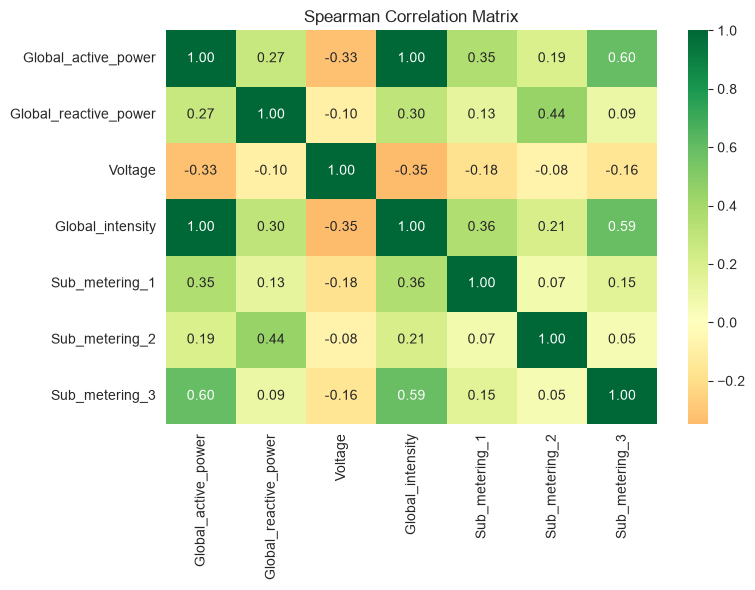

In [17]:
corr_matrix = df_5min[value_cols].corr(method="spearman")

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdYlGn", center=0, ax=ax)
ax.set_title("Spearman Correlation Matrix")
plt.tight_layout()
plt.show()

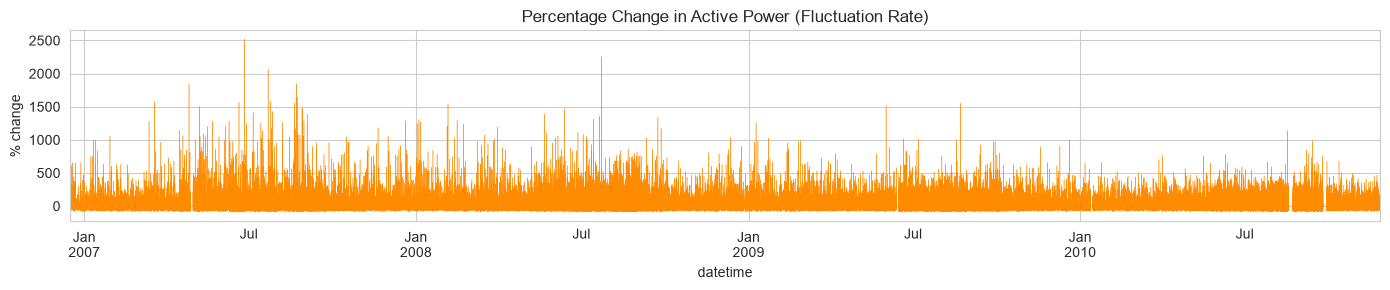

Mean absolute % change: 21.94%
Max % change: 2520.26%


In [18]:
df_5min["pct_change"] = df_5min["Global_active_power"].pct_change() * 100

fig, ax = plt.subplots(figsize=(14, 3))
df_5min["pct_change"].plot(ax=ax, linewidth=0.3, color="darkorange")
ax.set_title("Percentage Change in Active Power (Fluctuation Rate)")
ax.set_ylabel("% change")
plt.tight_layout()
plt.show()

print(f"Mean absolute % change: {df_5min['pct_change'].abs().mean():.2f}%")
print(f"Max % change: {df_5min['pct_change'].max():.2f}%")

In [19]:
output_path = "../data/processed/uci_household_5min.csv"
df_5min.drop(columns=["pct_change"]).to_csv(output_path)

print(f"Saved to {output_path}")
print(f"Shape: {df_5min.shape}")

Saved to ../data/processed/uci_household_5min.csv
Shape: (415053, 8)
